
# 📚 Books Market Analysis using Web Scraping and Exploratory Data Analysis

## Project Overview
This project analyzes a dataset of books scraped from **books.toscrape.com**.  
The goal is to perform **data cleaning, exploratory data analysis (EDA), visualization, and insights extraction** similar to professional data analysis projects.

Dataset Size:
- Rows: **500**
- Columns: **10**



## Problem Statement
The objective of this project is to explore the **online book market dataset** and identify patterns related to:
- Book prices
- Ratings
- Categories
- Availability
- Reviews

Through EDA we aim to understand:
- Which categories have higher priced books
- How ratings relate to book price
- Distribution of books across categories


### Introduction

- This project analyzes a Books dataset collected through web scraping from an online bookstore website.

- The objective of this analysis is to understand how books are priced, how ratings are distributed, and how different book categories influence the market.

- The analysis focuses on identifying patterns in:

    - Book pricing

    - Rating distribution

    - Category popularity

     - Availability of books

     - Market trends in online bookstores
 
- By performing Exploratory Data Analysis (EDA), we aim to discover key insights about book pricing strategies and reader rating behavior.

### Data Collection – Web Scraping

- The dataset used in this project was collected through web scraping instead of downloading a pre-existing dataset.

- The data was extracted from a public website that provides information about various books available in an online bookstore.

### Why Web Scraping?

Using web scraping provides several advantages:

- Real-time data extraction from websites

- Access to publicly available online information

- Ability to collect large datasets automatically

- Helps simulate real-world data collection scenarios

### Observation

The dataset collected from the website contains structured book information such as:

- Book title

- Price

- Rating

- Availability

- Category

However, some values such as price include currency symbols (£) which need to be cleaned and converted before performing analysis.

### Reason for Data Collection

The dataset in this project was collected through web scraping to simulate a real-world data collection process.

Instead of using a pre-existing dataset, the data was gathered directly from the website.

Web scraping allows extraction of publicly available information such as:

- Book title

- Price

- Rating

- Availability

- Category

This helps in building a realistic data analysis project workflow from data collection to insights generation.

### Web Scraping Process

The data collection process involved extracting book information directly from the website.

Steps involved:

1. Sending a request to the website

2. Parsing the HTML content using BeautifulSoup

3. Identifying book elements on the webpage

4. Extracting important fields:

- Title

- Price

- Rating

- Availability

5. Converting the extracted data into a Pandas DataFrame

The extracted data was then cleaned and prepared for further exploratory data analysis.

### Advantages of Web Scraping


- Provides real-time access to website data

- Allows automated data collection

- Useful for market analysis and research

- Helps build practical data science skills

## Import Libraries

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")


## Load Dataset

In [3]:

df = pd.read_csv("books_500_rows.csv")
df.head()


,Title,Category,Price,Availability,Rating,UPC,Price_excl_tax,Price_incl_tax,Number_of_reviews,URL
0,A Light in the Attic,Poetry,Â£51.77,In stock,Three,a897fe39b1053632,Â£51.77,Â£51.77,0,http://books.toscrape.com/catalogue/a-light-in...
1,Tipping the Velvet,Historical Fiction,Â£53.74,In stock,One,90fa61229261140a,Â£53.74,Â£53.74,0,http://books.toscrape.com/catalogue/tipping-th...
2,Soumission,Fiction,Â£50.10,In stock,One,6957f44c3847a760,Â£50.10,Â£50.10,0,http://books.toscrape.com/catalogue/soumission...
3,Sharp Objects,Mystery,Â£47.82,In stock,Four,e00eb4fd7b871a48,Â£47.82,Â£47.82,0,http://books.toscrape.com/catalogue/sharp-obje...
4,Sapiens: A Brief History of Humankind,History,Â£54.23,In stock,Five,4165285e1663650f,Â£54.23,Â£54.23,0,http://books.toscrape.com/catalogue/sapiens-a-...


## Dataset Shape

In [4]:

df.shape


(500, 10)


### Observation
The dataset contains **500 rows and 10 columns**, representing different attributes of books.


## Column Names

In [5]:

df.columns


Index(['Title', 'Category', 'Price', 'Availability', 'Rating', 'UPC',
       'Price_excl_tax', 'Price_incl_tax', 'Number_of_reviews', 'URL'],
      dtype='object')

## Convert Column Names to Lowercase

In [6]:

df.columns = df.columns.str.lower()
df.columns


Index(['title', 'category', 'price', 'availability', 'rating', 'upc',
       'price_excl_tax', 'price_incl_tax', 'number_of_reviews', 'url'],
      dtype='object')

## Dataset Information

In [7]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   title              500 non-null    object
 1   category           500 non-null    object
 2   price              500 non-null    object
 3   availability       500 non-null    object
 4   rating             500 non-null    object
 5   upc                500 non-null    object
 6   price_excl_tax     500 non-null    object
 7   price_incl_tax     500 non-null    object
 8   number_of_reviews  500 non-null    int64 
 9   url                500 non-null    object
dtypes: int64(1), object(9)
memory usage: 39.2+ KB



### Observation
This step helps us understand:
- Data types
- Non-null values
- Memory usage


## Check Missing Values

In [8]:

df.isnull().sum()


title                0
category             0
price                0
availability         0
rating               0
upc                  0
price_excl_tax       0
price_incl_tax       0
number_of_reviews    0
url                  0
dtype: int64


### Observation
If missing values exist, they can be handled using:
- Drop rows
- Fill with mean/median


## Check Duplicate Records

In [9]:

df.duplicated().sum()


np.int64(0)

In [10]:

df.drop_duplicates(inplace=True)



### Observation
Duplicate records are removed to maintain data quality.


## Convert Price Column to Numeric

In [11]:

df["price"] = df["price"].str.replace("Â£","").astype(float)
df.head()


,title,category,price,availability,rating,upc,price_excl_tax,price_incl_tax,number_of_reviews,url
0,A Light in the Attic,Poetry,51.77,In stock,Three,a897fe39b1053632,Â£51.77,Â£51.77,0,http://books.toscrape.com/catalogue/a-light-in...
1,Tipping the Velvet,Historical Fiction,53.74,In stock,One,90fa61229261140a,Â£53.74,Â£53.74,0,http://books.toscrape.com/catalogue/tipping-th...
2,Soumission,Fiction,50.10,In stock,One,6957f44c3847a760,Â£50.10,Â£50.10,0,http://books.toscrape.com/catalogue/soumission...
3,Sharp Objects,Mystery,47.82,In stock,Four,e00eb4fd7b871a48,Â£47.82,Â£47.82,0,http://books.toscrape.com/catalogue/sharp-obje...
4,Sapiens: A Brief History of Humankind,History,54.23,In stock,Five,4165285e1663650f,Â£54.23,Â£54.23,0,http://books.toscrape.com/catalogue/sapiens-a-...


## Rating Mapping

In [12]:

rating_map = {"One":1,"Two":2,"Three":3,"Four":4,"Five":5}
df["rating"] = df["rating"].map(rating_map)



### Observation
Ratings originally stored as text are converted to **numeric values for analysis**.


# Exploratory Data Analysis (EDA)

### 1️⃣ UNIVARIATE ANALYSIS (Single Variable)

### 1. Price Distribution (Histogram + KDE)

Shows how book prices are distributed.

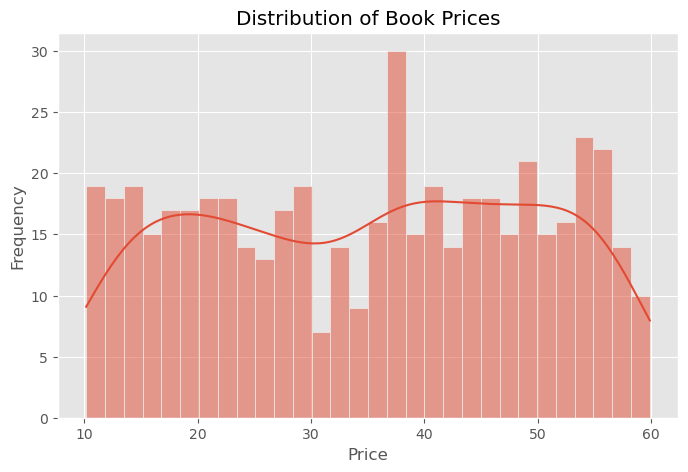

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Distribution of Book Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

### Insight

Most books fall in the mid-price range, with fewer books at very low or very high prices.

### 2. Rating Distribution

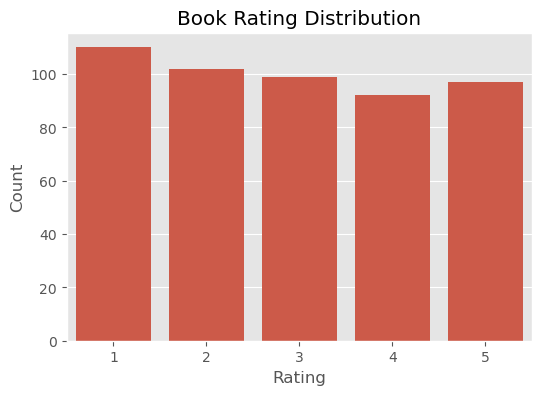

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="rating", data=df)
plt.title("Book Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

### Insight

Most books have ratings between 3 and 5, indicating generally positive feedback

###  Distribution of Book Ratings

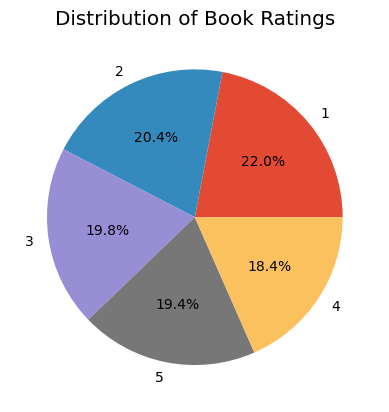

In [35]:
rating_counts = df["rating"].value_counts()

plt.figure()

rating_counts.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")
plt.title("Distribution of Book Ratings")

plt.show()

### Insight
The pie chart shows the percentage distribution of books across different rating levels.
Most books fall between ratings 1–3, indicating a balanced distribution of ratings.

### 2️⃣ BIVARIATE ANALYSIS (Two Variables)

### 4. Price vs Rating

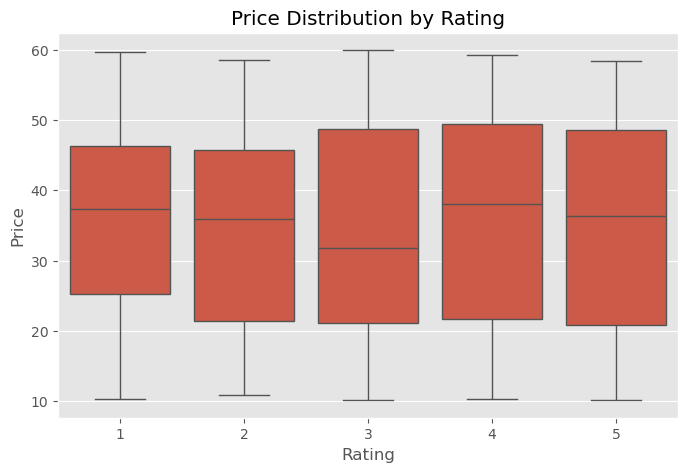

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x="rating", y="price", data=df)
plt.title("Price Distribution by Rating")
plt.xlabel("Rating")
plt.ylabel("Price")
plt.show()

### Insight

Books with higher ratings sometimes have slightly higher prices.

### 5. Category vs Average Price

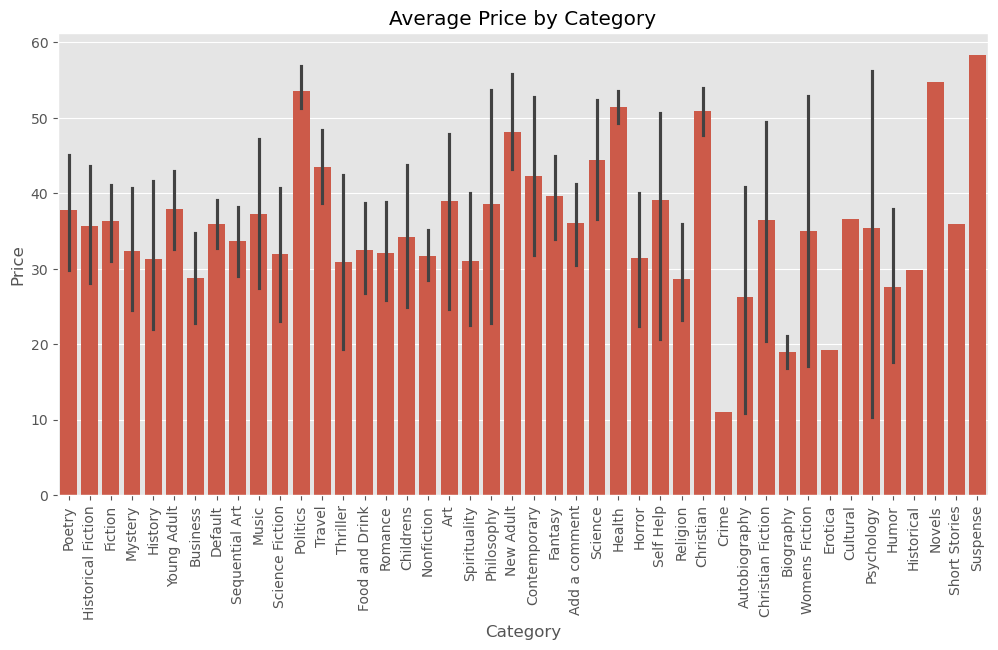

In [17]:
plt.figure(figsize=(12,6))

# Barplot for Category vs Average Price
sns.barplot(x="category", y="price", data=df)

plt.xticks(rotation=90)
plt.title("Average Price by Category")
plt.xlabel("Category")
plt.ylabel("Price")

plt.show()

### Insight

Some categories contain more expensive books compared to others.

### 6. Availability vs Price

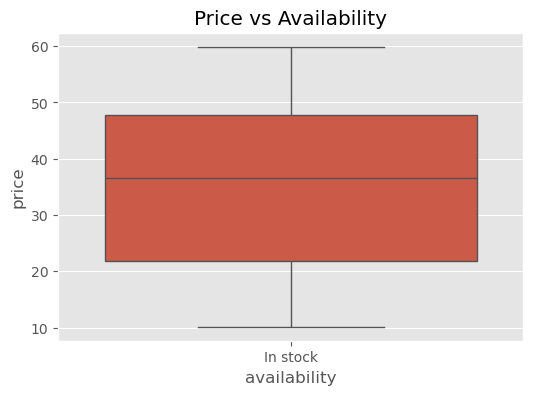

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x="availability", y="price", data=df)
plt.title("Price vs Availability")
plt.show()

### Insight

Availability does not significantly affect price in this dataset.

### 3️⃣ MULTIVARIATE ANALYSIS

### 7.Price vs Rating by Availability

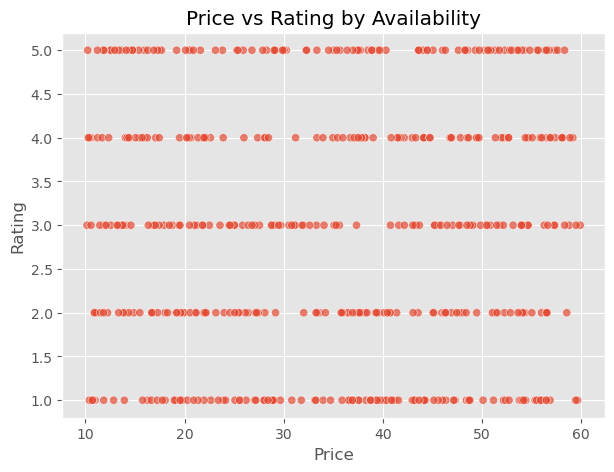

In [41]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="price",
    y="rating",
    hue="availability",
    data=df,
    alpha=0.7
)

plt.xlabel("Price")
plt.ylabel("Rating")
plt.title("Price vs Rating by Availability")

plt.legend().remove()   # removes the legend

plt.show()

### Insight

Ratings are spread across all price ranges, indicating that book price has little influence on ratings regardless of availability.

### 8. Correlation Heatmap

In [31]:
df["number_of_reviews"].isna().sum()

np.int64(0)

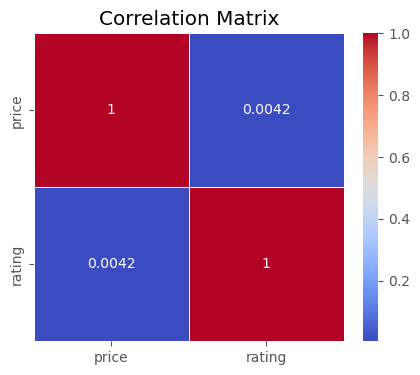

In [32]:
plt.figure(figsize=(5,4))

corr_matrix = df[["price","rating"]].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

### Insight

The heatmap shows the correlation between price and rating.
The correlation value is close to zero, indicating a very weak relationship.
This suggests that higher priced books do not necessarily receive higher ratings.

### 9. Pairplot (Very Powerful)

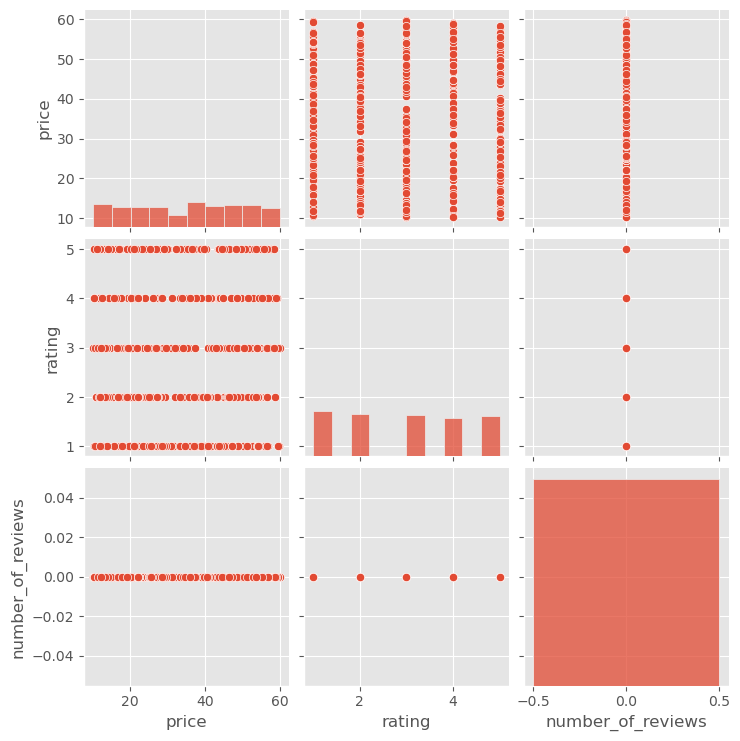

In [61]:
sns.pairplot(df[["price","rating","number_of_reviews"]])
plt.show()

### Insight

Pairplots show relationships between multiple numeric variables at once.

### 4️⃣ Pivot Table Visualization

In [62]:

pivot1 = pd.pivot_table(df, values="price", index="category", aggfunc="mean")
pivot1


,price
category,
Add a comment,36.007407
Art,39.034000
Autobiography,26.320000
Biography,19.000000
Business,28.775556
Childrens,34.257500
Christian,50.860000
Christian Fiction,36.533333
Contemporary,42.280000



### Insight
Pivot tables reveal **average price per category**, helping identify premium categories.


In [63]:

pivot2 = pd.pivot_table(df, values="price", index="rating", aggfunc="mean")
pivot2


,price
rating,
1,35.999000
2,33.677745
3,34.222424
4,36.272717
5,35.052268



### Insight
Average price by rating shows how book quality perception may affect pricing.


### Heatmap:

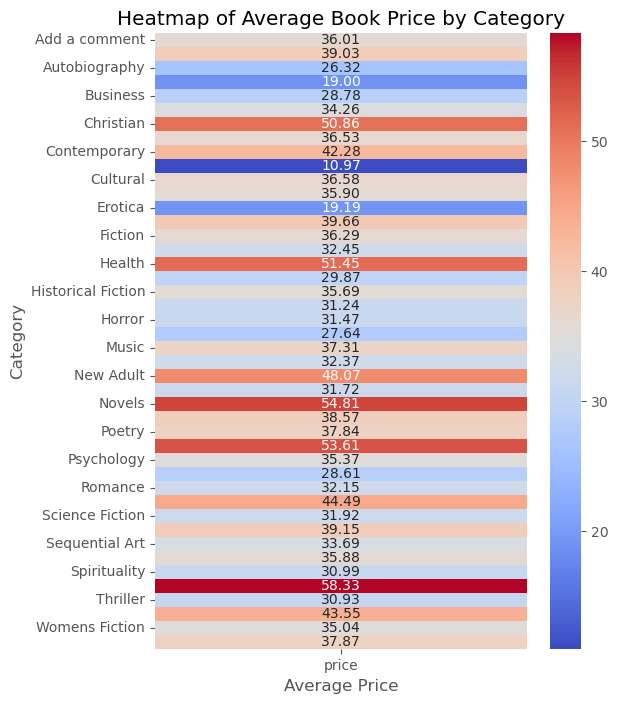

In [75]:
plt.figure(figsize=(6,8))

pivot1 = pd.pivot_table(df, values="price", index="category", aggfunc="mean")

sns.heatmap(pivot1, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Heatmap of Average Book Price by Category")
plt.xlabel("Average Price")
plt.ylabel("Category")

plt.show()


# Final Conclusions

Key findings from the analysis:

1. Most books fall within a **moderate price range**.
2. Ratings are mostly **3–5**, indicating good reader feedback.
3. Some categories contain **premium priced books**.
4. Higher ratings sometimes correlate with **slightly higher prices**.

Overall, the dataset shows that **category and rating influence book pricing patterns**.
